# Paper 2 - WGCs

## Data preparation

### Paper 2-specific SQL database subset

In [3]:
import os
# Import the paper-specific paths configuration dataclass
from genomics_config import paths_config, filtering_config, master_config
# Import the specific data preparation function (database subsetting for Paper 2)
from genomics_dataprep import genomics_database_subset

# Create an instance of the paths_config dataclass
paths = paths_config(
    source_dir = r"../dbs", # Raw and pre-processed PNK databases - DB2_standard folder
    source_db = r"../dbs/pnk_db2_filtered.sqlite", # The specific, filtered source database - pnk_db2_filtered
    paper_dir = r"..", # Paper 2-specific files and code
    paper_in_db = r"../dbs/pnk_db2_p2_in.sqlite", # The input database created and used in Paper 2 - pnk_db2_p2_in
    paper_out_db = r"../dbs/pnk_db2_p2_out.sqlite", # The output database created and used in Paper 2 - pnk_db2_p2_out
)

filtering = filtering_config(
    filtering_sql_query="""
        SELECT medical_record_id, patient_id
        FROM medical_records_filtered
        """
        # WHERE gdpr4 = 1
        #   AND gdpr10 = 0
        #   AND medical_record_sequence = 1
)

config = master_config(
    paths=paths,
    filtering=filtering
)

# Create the output directory if it doesn't exist to prevent errors
os.makedirs(config.paths.paper_dir, exist_ok=True)

# Call the data subsetting function
genomics_database_subset(config)

Wrote 17680 rows from medical_records_filtered to medical_records_genomics.
Wrote 347707 rows from measurements_filtered to measurements_genomics.
Data has been saved to ../dbs/pnk_db2_p2_in.sqlite.
Total records: 17680 from 14390 patients.


### Paper 2-specific time-to-event tables

In [5]:
import os
# Import the paper-specific and analysis-specific configuration dataclasses
from genomics_config import paths_config, timetoevent_config, timetoevent_subsetting_config, master_config
# Import the specific data preparation function (time-to-event table calculations for Paper 2)
from genomics_dataprep import build_timetoevent_table, subset_timetoevent_table

paths = paths_config(
    source_dir = r"c:/Users/Felhasználó/Desktop/Projects/PNK_DB2/genomics_dir/dbs", 
    source_db = r"c:/Users/Felhasználó/Desktop/Projects/PNK_DB2/genomics_dir/dbs/pnk_db2_filtered.sqlite", # copy of the filtered DB stored in the project directory
    paper_dir = r"..", # Paper 2-specific files and code
    paper_in_db = r"c:/Users/Felhasználó/Desktop/Projects/PNK_DB2/genomics_dir/dbs/pnk_db2_genomics_in.sqlite", 
    paper_out_db = r"c:/Users/Felhasználó/Desktop/Projects/PNK_DB2/genomics_dir/dbs/pnk_db2_genomics_out.sqlite", 
)

timetoevent = timetoevent_config(
    # paper_in_db=paths_config.paper_in_db,
    # paper_out_db=paths_config.paper_out_db,
    input_measurements="measurements_filtered",
    input_records="medical_records_filtered",
    output_table="timetoevent_all",
    weight_loss_targets=[5, 10, 15],
    time_windows=[40, 60, 80],
    window_span=10,
    fetch_from_records=[
        "patient_id", "medical_record_id",
        "dietitian_visits", 
        "sex_f", "age_when_creating_record AS age",
        "height_m",
        "weight_gain_cause", "weight_gain_cause_en", 
        "womens_health_and_pregnancy", "mental_health", "family_issues",
        "medication_disease_injury", "physical_inactivity", "eating_habits", 
        "schedule", "smoking_cessation", "treatment_discontinuation_or_relapse", "pandemic",
        "lifestyle_circumstances", "none_of_above", 
        "genomics_sample_id"
    ],
    followup_columns=[
        "patient_id","medical_record_id",
        "baseline_date","last_aval_date","total_followup_days",
        "dietitian_visits","nr_total_measurements", "instant_dropout", "avg_days_between_measurements",
        "baseline_weight_kg","last_aval_weight_kg","total_wl_kg","total_wl_%", 
        "baseline_bmi","final_bmi","bmi_reduction", "baseline_fat_%","last_aval_fat_%","total_fat_loss_%",
        "baseline_muscle_%","last_aval_muscle_%","total_muscle_change_%"
    ],
    predictor_columns=[
        "sex_f","age","height_m",
        "weight_gain_cause", "weight_gain_cause_en", 
        "womens_health_and_pregnancy", "mental_health", "family_issues",
        "medication_disease_injury", "physical_inactivity", "eating_habits", 
        "schedule", "smoking_cessation", "treatment_discontinuation_or_relapse", "pandemic",
        "lifestyle_circumstances", "none_of_above", 
        "genomics_sample_id", "gdpr4", "gdpr10"
    ]
)

config = master_config(
    paths=paths,
    timetoevent=timetoevent,
    timetoevent_subsetting=timetoevent_subsetting
)

build_timetoevent_table(config)


Connecting to source database: c:/Users/Felhasználó/Desktop/Projects/PNK_DB2/genomics_dir/dbs/pnk_db2_filtered.sqlite
Saved 17680 rows to c:/Users/Felhasználó/Desktop/Projects/PNK_DB2/genomics_dir/dbs/pnk_db2_genomics_in.sqlite::timetoevent_all


In [ ]:
timetoevent_subsetting = timetoevent_subsetting_config(
    source_table="timetoevent_all",
    definitions={
        "timetoevent_gen_compl": ["genomics_sample_id", ("gdpr10", 1)],
    }
)
# Update config with the new subsetting rules
config.timetoevent_subsetting = timetoevent_subsetting
subset_timetoevent_table(config)


--- Starting Table Subsetting from 'timetoevent_all' ---
  - Warning: Skipping table 'timetoevent_gen_compl' because columns [('gdpr10', 1)] were not found.
--- Table Subsetting Complete ---


## Block I - Impact of individual weight gain causes on weight loss

### I/1. Comparative analyses by demographic and WGC groups

In [ ]:
# --- Import necessary configs and the new execution function ---
from genomics_config import master_config, paths_config, descriptive_comparisons_config
from descriptive_comparisons import run_descriptive_comparisons

# --- 1. Define Paths ---
paths = paths_config(
    source_dir = r"../dbs", # Raw and pre-processed PNK databases - DB2_standard folder
    source_db = r"../dbs/pnk_db2_filtered.sqlite", # The specific, filtered source database - pnk_db2_filtered
    paper_dir = r"..", # Paper 2-specific files and code
    paper_in_db = r"../dbs/pnk_db2_p2_in.sqlite", # The input database created and used in Paper 2 - pnk_db2_p2_in
    paper_out_db = r"../dbs/pnk_db2_p2_out.sqlite", # The output database created and used in Paper 2 - pnk_db2_p2_out
)
# --- 2. Define the ROW_ORDER once, or customize it per analysis ---
# This can be a global variable in your notebook for convenience

TIME_WINDOWS = [40, 60, 80]
WL_TARGETS = [5, 10, 15]

ROW_ORDER = [
    ("N", "N"),
    # Demographics & baseline anthropometry
    ("delim_demo", "Demographics and baseline anthropometry"),
    ("sex_f", "Sex (% of females)"),
    ("age", "Age (years)"),
    ("height_m", "Height (m)"),
    ("baseline_weight_kg", "Baseline weight (kg)"),
    ("baseline_bmi", "Baseline BMI (kg/m²)"),
    ("baseline_fat_%", "Baseline fat mass (%)"),
    ("baseline_muscle_%", "Baseline muscle mass (%)"),
    # Treatment outcomes
    ("delim_outcomes", "Treatment outcomes"),
    ("total_followup_days", "Follow-up length (days)"),
    ("dietitian_visits", "Number of visits"),
    ("nr_total_measurements", "Number of total measurements"),
    ("avg_days_between_measurements", "Average measurement frequency (days)"),
    ("last_aval_weight_kg", "Last measured weight (kg)"),
    ("total_wl_kg", "Total weight loss (kg)"),
    ("total_wl_%", "Total weight loss (%)"),
    ("final_bmi", "Final BMI (kg/m²)"),
    ("bmi_reduction", "BMI reduction (kg/m²)"),
    ("last_aval_fat_%", "Last measured fat mass (%)"),
    ("total_fat_loss_%", "Total fat mass loss (%)"),
    ("last_aval_muscle_%", "Last measured muscle mass (%)"),
    ("total_muscle_change_%", "Total muscle mass change (%)"),
    ("instant_dropout", "Instant dropouts (n)"),
]
# Add dynamic time window and WL target variables
for w in TIME_WINDOWS:
    ROW_ORDER += [
        (f"{w}d_dropout", f"{w}-day dropouts (n)"),
        (f"{w}d_wl_%", f"{w}-day weight loss (%)"),
        (f"{w}d_bmi_reduction", f"{w}-day BMI reduction (kg/m²)"),
        (f"{w}d_fat_loss_%", f"{w}-day fat mass loss (%)"),
        (f"{w}d_muscle_change_%", f"{w}-day muscle mass change (%)"),
    ]
for t in WL_TARGETS:
    ROW_ORDER += [
        (f"{t}%_wl_achieved", f"Achieved {t}% weight loss (n)"),
        (f"days_to_{t}%_wl", f"Days to {t}% weight loss"),
    ]
ROW_ORDER += [
    # Weight gain causes
    ("delim_wgc", "Self-reported causes of weight gain"),
    ("womens_health_and_pregnancy", "Women's health and pregnancy (yes/no)"),
    ("mental_health", "Mental health (yes/no)"),
    ("family_issues", "Family issues (yes/no)"),
    ("medication_disease_injury", "Medication, disease or injury (yes/no)"),
    ("physical_inactivity", "Physical inactivity (yes/no)"),
    ("eating_habits", "Eating habits (yes/no)"),
    ("schedule", "Schedule (yes/no)"),
    ("smoking_cessation", "Smoking cessation (yes/no)"),
    ("treatment_discontinuation_or_relapse", "Treatment discontinuation or relapse (yes/no)"),
    ("pandemic", "COVID-19 pandemic (yes/no)"),
    ("lifestyle_circumstances", "Lifestyle circumstances (yes/no)"),
    ("none_of_above", "None of the above (yes/no)"),
]

# --- 3. Define your first descriptive analysis ---

# analysis1 = descriptive_comparisons_config(
#     analysis_name="wgc_cmpl_vs_all",
#     input_cohort_name="timetoevent_wgc_compl",
#     mother_cohort_name="timetoevent_all",
#     demographic_output_table="wgc_cmpl_dmgrph_strt",
#     wgc_output_table="wgc_cmpl_wgc_strt",
#     wgc_vs_mean_output_table="wgc_cmpl_wgc_vs_mean",
#     # bias_plot_filename="wgc_cmpl_datacollection_bias.png",
#     row_order=ROW_ORDER,
#     fdr_correction=True,
#     demographic_strata=[
#         "age",
#         "sex_f",
#         "baseline_bmi"
#     ],
#     wgc_strata=[
#         "womens_health_and_pregnancy",
#         "mental_health",
#         "family_issues",
#         "medication_disease_injury",
#         "physical_inactivity",
#         "eating_habits",
#         "schedule",
#         "smoking_cessation",
#         "treatment_discontinuation_or_relapse",
#         "pandemic",
#         "lifestyle_circumstances",
#         "none_of_above"
#     ],
# )

# analysis2 = descriptive_comparisons_config(
#     analysis_name="wgc_gen_compl_vs_wgccompl",
#     input_cohort_name="timetoevent_wgc_gen_compl",
#     mother_cohort_name="timetoevent_wgc_compl",
#     demographic_output_table="wgc_gen_cmpl_dmgrph_strt",
#     wgc_output_table="wgc_gen_cmpl_wgc_strt",
#     wgc_vs_mean_output_table="wgc_gen_cmpl_wgc_vs_mean",
#     # bias_plot_filename="wgc_gen_cmpl_datacollection_bias.png",
#     row_order=ROW_ORDER,
#     fdr_correction=True,
#     demographic_strata=[
#         "age",
#         "sex_f",
#         "baseline_bmi"
#     ],
#     wgc_strata=[
#         "womens_health_and_pregnancy",
#         "mental_health",
#         "family_issues",
#         "medication_disease_injury",
#         "physical_inactivity",
#         "eating_habits",
#         "schedule",
#         "smoking_cessation",
#         "treatment_discontinuation_or_relapse",
#         "pandemic",
#         "lifestyle_circumstances",
#         "none_of_above"
#     ],
# )

# quick test for the genomics exploration: genomics vs all
analysis3 = descriptive_comparisons_config(
    analysis_name="gen_compl_vs_all",
    input_cohort_name="timetoevent_gen_compl",
    mother_cohort_name="timetoevent_all",
    demographic_output_table="gen_cmpl_dmgrph_strt",
    wgc_output_table="gen_cmpl_wgc_strt",
    wgc_vs_mean_output_table="gen_cmpl_wgc_vs_mean",
    # bias_plot_filename="wgc_gen_cmpl_datacollection_bias.png",
    row_order=ROW_ORDER,
    fdr_correction=True,
    demographic_strata=[
        "age",
        "sex_f",
        "baseline_bmi"
    ],
    wgc_strata=[
        "womens_health_and_pregnancy",
        "mental_health",
        "family_issues",
        "medication_disease_injury",
        "physical_inactivity",
        "eating_habits",
        "schedule",
        "smoking_cessation",
        "treatment_discontinuation_or_relapse",
        "pandemic",
        "lifestyle_circumstances",
        "none_of_above"
    ],
)

# --- 5. Assemble the Master Config ---
config = master_config(
    paths=paths,
    descriptive_comparisons=[analysis3]
)

# --- 6. Execute! ---
# This one function call runs all the analyses you defined.
run_descriptive_comparisons(config)


Starting descriptive comparisons pipeline with 1 analysis configurations.

Executing analysis 1/1: 'gen_compl_vs_all'
  FDR correction: ENABLED
  Loaded data: 3258 input records, 17680 mother records.
Running Demographic Stratification...
  Processing variable 2/58: sex_f
  Processing variable 3/58: age
  Processing variable 4/58: height_m
  Processing variable 5/58: baseline_weight_kg
  Processing variable 6/58: baseline_bmi
  Processing variable 7/58: baseline_fat_%
  Processing variable 8/58: baseline_muscle_%
  Processing variable 10/58: total_followup_days
  Processing variable 11/58: dietitian_visits
  Processing variable 12/58: nr_total_measurements
  Processing variable 13/58: avg_days_between_measurements
  Processing variable 14/58: last_aval_weight_kg
  Processing variable 15/58: total_wl_kg
  Processing variable 16/58: total_wl_%
  Processing variable 17/58: final_bmi
  Processing variable 18/58: bmi_reduction
  Processing variable 19/58: last_aval_fat_%
  Processing variab

### I/Expl vis

Loading WGC data from timetoevent_wgc_compl...
  ✓ Loaded 2463 records
  ✓ Available WGC columns: 12

Generating forest plot(s) for '10%_wl_achieved'...


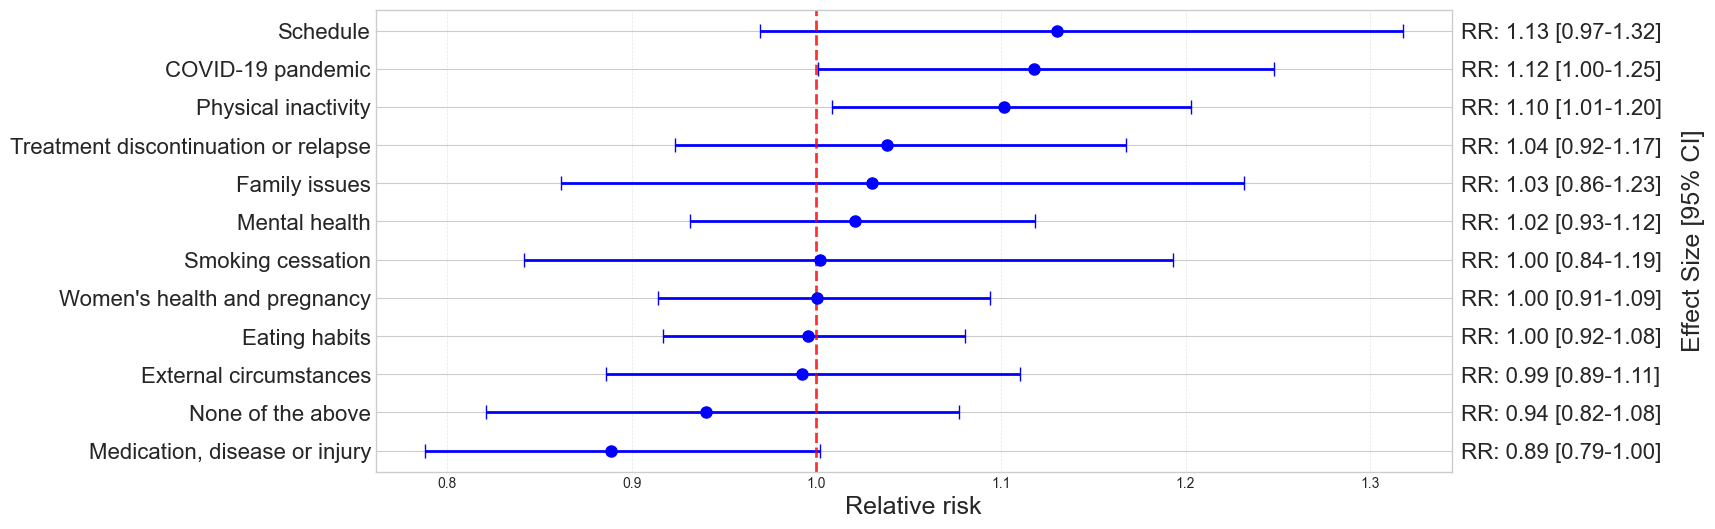

  ✓ Risk Ratio plot saved


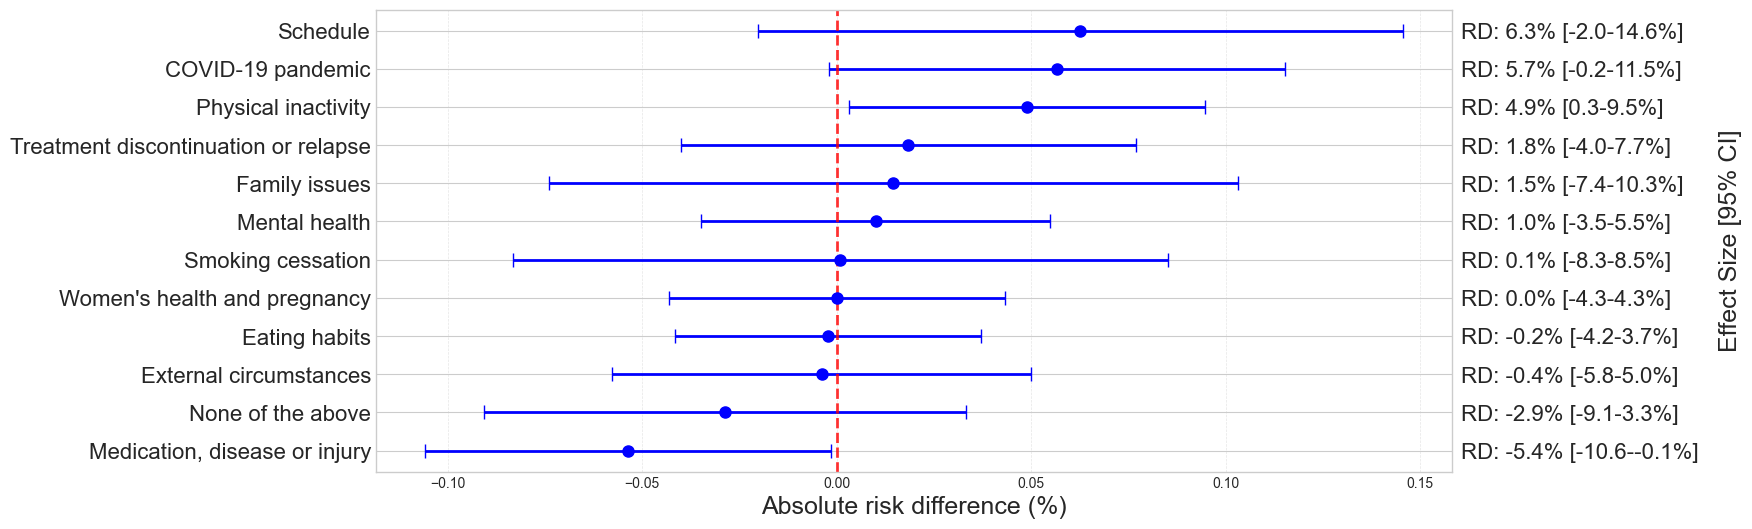

  ✓ Risk Difference plot saved

Generating forest plot(s) for '60d_dropout'...


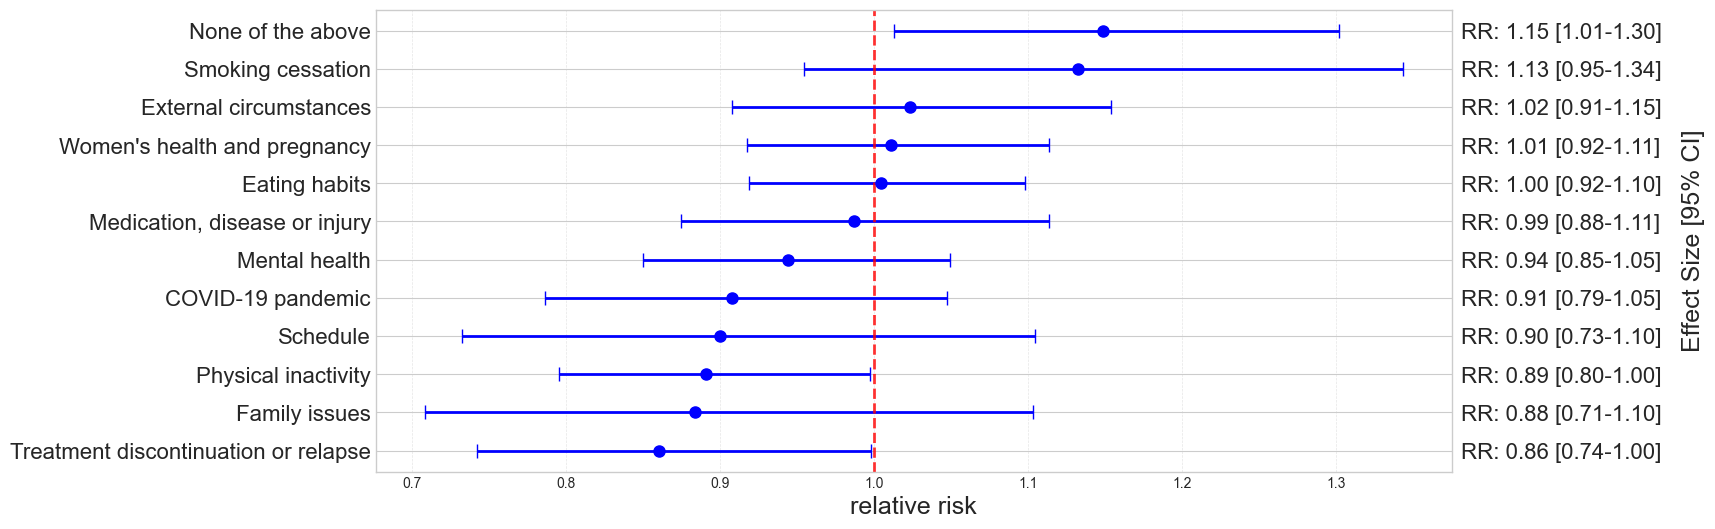

  ✓ Risk Ratio plot saved


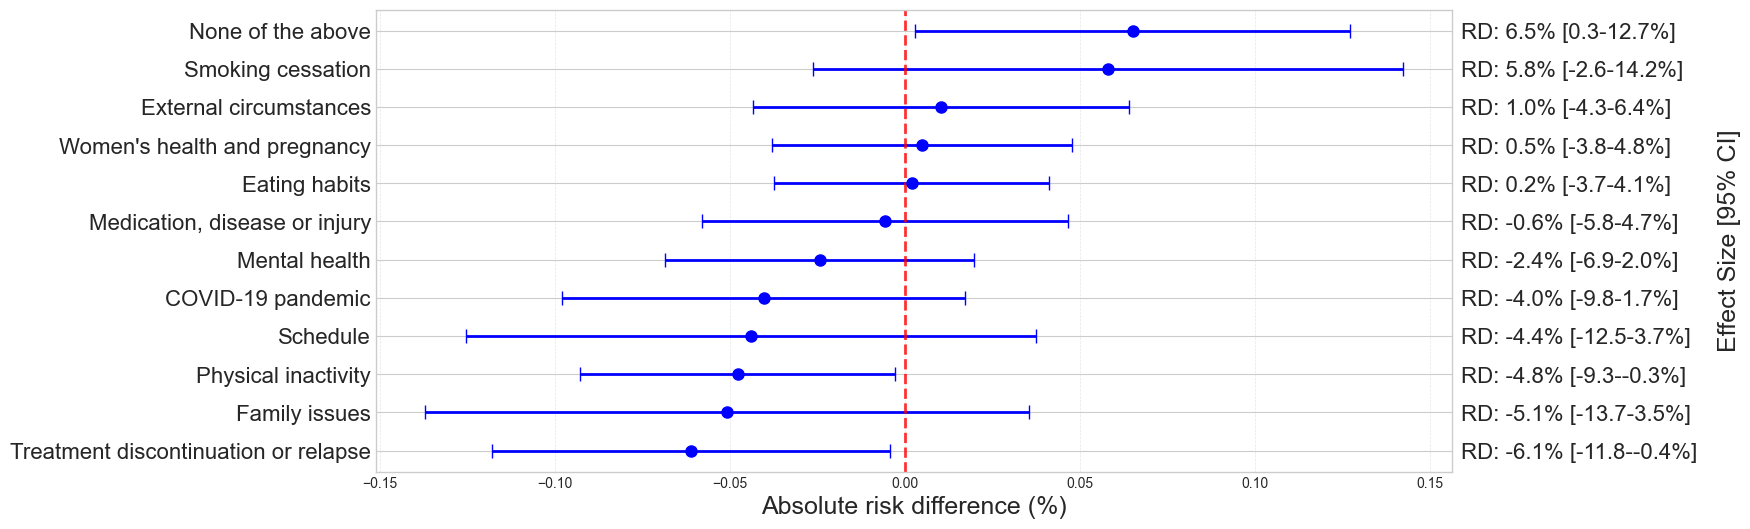

  ✓ Risk Difference plot saved


In [3]:
from wgc_visualizations import *

# Load data
wgc_df = load_wgc_data(
    db_path="../dbs/pnk_db2_p2_in.sqlite",
    table_name="timetoevent_wgc_compl"
)

# wgc_continuous_distributions(
#     wgc_df,
#     variables=[
#         "age",
#         "baseline_weight_kg",
#         "baseline_bmi", 
#         "total_wl_%", 
#         "bmi_reduction",
#         "days_to_10%_wl",
#         "total_followup_days",        
#     ],
#     output_dir='../outputs/wgc_viz_test_20Nov25',
#     # Global settings
#     title='Distribution of {variable} by WGC group',
#     ylabel='{variable}',
#     xlabel='Weight gain cause groups',
#     # Per-variable overrides
#     variable_configs={
#         'age': {
#             'title': 'Age distribution across WGC groups',
#             # 'xlabel': 'Patient clusters',
#             'ylabel': 'Age (years)',

#         },
#         'baseline_bmi': {
#             'title': 'Baseline BMI distribution across WGC groups',
#             # 'xlabel': 'Patient clusters',
#             'ylabel': 'BMI (kg/m²)'
#         },
#         'baseline_weight_kg': {
#             'title': 'Baseline weight distribution across WGC groups',
#             # 'xlabel': 'Patient clusters',
#             'ylabel': 'Weight (kg)'
#         },
#         'total_wl_%"': {
#             'title': 'Total weight loss across WGC groups',
#             # 'xlabel': 'Patient clusters',
#             'ylabel': 'Total weight loss (%)'
#         },
#         'bmi_reduction': {
#             'title': 'BMI reduction across WGC groups',
#             # 'xlabel': 'Patient clusters',
#             'ylabel': 'BMI (kg/m²)'
#         },  
#         'days_to_10%_wl': {
#             'title': 'Weight loss speed as days to 10% weight loss across WGC groups',
#             # 'xlabel': 'Patient clusters',
#             'ylabel': 'Days to 10% weight loss (days)'
#         },  
#         'total_followup_days': {
#             'title': 'Total follow-up length across WGC groups',
#             # 'xlabel': 'Patient clusters',
#             'ylabel': 'Total follow-up (days)'
#         },  
#     }
# )

# wgc_categorical_distributions(
#     wgc_df,
#     variables=[
#         'sex_f', 
#         '10%_wl_achieved', 
#         '60d_dropout'],
#     output_dir='../outputs/wgc_viz_test_20Nov25',
#     # Global settings
#     ylabel='Percentage (%)',
#     xlabel='WGC groups',
#     legend_labels={'achieved': 'Yes', 'not_achieved': 'No'},
#     # Per-variable overrides
#     variable_configs={
#         'sex_f': {
#             'title': 'Sex distribution by WGC group',
#             'legend_labels': {'achieved': 'Women', 'not_achieved': 'Men'}
#         },
#         '10%_wl_achieved': {
#             'title': '10% weight loss achievement rate',
#             'legend_labels': {'achieved': 'Achieved', 'not_achieved': 'Not Achieved'}
#         },
#         '60d_dropout': {
#             'title': 'Dropout rate at 2 months',
#             'legend_labels': {'achieved': 'Dropped Out', 'not_achieved': 'Retained'}
#         }
#     }
# )

plot_wgc_forest(
    wgc_df,
    outcome_variable='10%_wl_achieved',
    output_dir='../outputs/wgc_visualizations',
    effect_type='both',
    title_rr='Risk ratios: 10% weight loss',
    title_rd='Risk differences: 10% weight loss',
    ylabel='Weight gain causes',
    xlabel_rr='Relative risk',
    xlabel_rd='Absolute risk difference (%)'
)

plot_wgc_forest(
    wgc_df,
    outcome_variable='60d_dropout',
    output_dir='../outputs/wgc_visualizations',
    effect_type='both',
    title_rr='Risk Ratios: Dropout at 2 months',
    title_rd='Risk Differences: Dropout at 2 months',
    ylabel='Weight gain causes',
    xlabel_rr='relative risk',
    xlabel_rd='Absolute risk difference (%)'
)

#### mother-daughter cohort comparison on key outcomes

In [1]:
# ===================================================================
# WGC vs Mother Cohort Lollipop Plot - Enhanced with Variable Ordering
# ===================================================================

import sys
import os
sys.path.append('../scripts')

# Import the lollipop plotting functions
from wgc_mother_cohort_lollipop import (
    main, create_lollipop_from_raw_data, 
    get_available_variables, get_variable_categories
)
import pandas as pd
import numpy as np

# ===================================================================
# Configuration with Variable Ordering Control
# ===================================================================

# Choose your approach
PRESERVE_VARIABLE_ORDER = True  # Set to True to preserve your specified order

# Define your variables in the order you want them to appear in the plot
# NOTE: First variable in list will appear at the TOP of the plot
# Last variable in list will appear at the BOTTOM of the plot
variables_in_desired_order = [
    # Demographics (bottom of plot)
    'Sex (% of females)',
    'Age (years)', 
    'Baseline weight (kg)',
    # 'Baseline BMI (kg/m²)',
    
    # Engagement metrics
    'Follow-up length (days)',
    'Number of visits',
    'Instant dropouts (n)',
    '40-day dropouts (n)',
    '60-day dropouts (n)',
    
    # Weight loss outcomes (top of plot - most important)
    'Total weight loss (%)',
    # 'Total weight loss (kg)',
    # 'BMI reduction (kg/m²)',
    'Achieved 5% weight loss (n)',
    'Days to 5% weight loss',
    'Achieved 10% weight loss (n)',
    'Days to 10% weight loss',
    'Achieved 15% weight loss (n)',
    'Days to 15% weight loss', 
    # 'Total fat mass loss (%)',
    # 'Total muscle mass change (%)'
]

# Main configuration
config = {
    'db_path': "../dbs/pnk_db2_p2_out.sqlite",
    'table_name': "wgc_cmpl_dmgrph_strt",
    'output_plot_path': "../outputs/wgc_mother_cohort_lollipop_ordered.png",
    'output_table_path': "../outputs/wgc_mother_cohort_summary_ordered.csv",
    'variables_to_include': variables_in_desired_order,
    'title': "Key Differences: WGC vs All Patients",
    'figsize': (12, 10),
    'preserve_order': PRESERVE_VARIABLE_ORDER
}

# ===================================================================
# Execute the Plot Generation
# ===================================================================

print("=" * 60)
print("WGC vs Mother Cohort Lollipop Plot Generation")
print("=" * 60)
print(f"Variable ordering: {'PRESERVED (first item = top of plot)' if PRESERVE_VARIABLE_ORDER else 'AUTOMATIC (by magnitude)'}")

try:
    pct_data, summary_table = main(
        db_path=config['db_path'],
        table_name=config['table_name'],
        output_plot_path=config['output_plot_path'],
        output_table_path=config['output_table_path'],
        variables_to_include=config['variables_to_include'],
        title=config['title'],
        figsize=config['figsize'],
        preserve_order=config['preserve_order']
    )
    
    print("\n" + "=" * 60)
    print("RESULTS SUMMARY")
    print("=" * 60)
    
    # Show variables in the order they appear in the plot (top to bottom)
    print(f"\nVariables in plot order (TOP to BOTTOM):")
    for i, (_, row) in enumerate(pct_data.iterrows(), 1):
        significance = row['significance']
        pct_change = row['percent_change']
        print(f"{i:2d}. {row['variable']}: {pct_change:+.1f}% {significance}")
    
    # Display key findings
    significant_vars = pct_data[pct_data['significance'].str.contains('\*', na=False)]
    print(f"\nStatistically significant differences ({len(significant_vars)} total):")
    
    for _, row in significant_vars.iterrows():
        print(f"  {row['variable']}: {row['percent_change']:+.1f}% {row['significance']}")
    
    # Show largest absolute differences
    print(f"\nLargest absolute differences:")
    largest_diffs = pct_data.reindex(pct_data['percent_change'].abs().sort_values(ascending=False).index)
    
    for _, row in largest_diffs.head(5).iterrows():
        print(f"  {row['variable']}: {row['percent_change']:+.1f}% {row['significance']}")
    
    print(f"\nPlot saved to: {config['output_plot_path']}")
    print(f"Summary table saved to: {config['output_table_path']}")
    
    # Display summary statistics
    print(f"\nSummary Statistics:")
    print(f"  Total variables analyzed: {len(pct_data)}")
    print(f"  Significant differences: {len(significant_vars)}")
    print(f"  Variables with >5% change: {len(pct_data[pct_data['percent_change'].abs() > 5])}")
    print(f"  Variables with >10% change: {len(pct_data[pct_data['percent_change'].abs() > 10])}")

except Exception as e:
    print(f"Error generating lollipop plot: {str(e)}")
    import traceback
    traceback.print_exc()

print("\n" + "=" * 60)
print("Plot generation complete!")
print("=" * 60)

<>:100: SyntaxWarning: invalid escape sequence '\*'
<>:100: SyntaxWarning: invalid escape sequence '\*'
C:\Users\Felhasználó\AppData\Local\Temp\ipykernel_28944\1291606756.py:100: SyntaxWarning: invalid escape sequence '\*'
  significant_vars = pct_data[pct_data['significance'].str.contains('\*', na=False)]


WGC vs Mother Cohort Lollipop Plot Generation
Variable ordering: PRESERVED (first item = top of plot)
Generating WGC vs Mother Cohort Lollipop Plot...
Extracting comparison data...
Sample sizes - WGC cohort: 2463, Mother cohort: 17680
Calculating percentage changes...
Filtered to 15 requested variables (order preserved)
Found 15 variables for comparison:
  Sex (% of females): +3.5% **
  Age (years): -2.0% **
  Baseline weight (kg): -0.6% 
  Follow-up length (days): +2.8% 
  Number of visits: +26.2% **
  Instant dropouts (n): -18.0% *
  40-day dropouts (n): -8.5% **
  60-day dropouts (n): -4.8% *
  Total weight loss (%): +6.1% **
  Achieved 5% weight loss (n): +3.2% **
  Days to 5% weight loss: -5.6% **
  Achieved 10% weight loss (n): +8.6% **
  Days to 10% weight loss: -3.4% 
  Achieved 15% weight loss (n): +9.3% **
  Days to 15% weight loss: +0.3% 
Creating lollipop plot...
Preserving variable order as specified (reversed for top-to-bottom display)
Lollipop plot saved to: ../outputs/w

#### binary distro bar charts

In [2]:
# Import and run comprehensive categorical analysis
import sys
sys.path.append('scripts')
from wgc_sex_stacked_bars import StackedBarConfig, get_wgc_columns, generate_all_categorical_plots
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

def run_comprehensive_wgc_analysis():
    db_path = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper2_dir\dbs\pnk_db2_p2_in.sqlite"
    with sqlite3.connect(db_path) as conn:
        df = pd.read_sql_query("SELECT * FROM timetoevent_wgc_compl", conn)
    
    wgc_cols = get_wgc_columns(df)
    config = StackedBarConfig()
    
    # Generate all categorical distribution plots
    generated_files = generate_all_categorical_plots(df, wgc_cols, config)
    
    print(f"Generated {len(generated_files)} comprehensive analysis charts!")
    return generated_files

# Usage: 
files = run_comprehensive_wgc_analysis()



Generating plot for Sex...
Performing statistical tests...
  womens_health_and_pregnancy: p-value = 0.0000 (chi_squared)
  mental_health: p-value = 0.0013 (chi_squared)
  family_issues: p-value = 0.0004 (chi_squared)
  medication_disease_injury: p-value = 0.1803 (chi_squared)
  physical_inactivity: p-value = 0.0000 (chi_squared)
  eating_habits: p-value = 0.0038 (chi_squared)
  schedule: p-value = 0.0244 (chi_squared)
  smoking_cessation: p-value = 0.0770 (chi_squared)
  treatment_discontinuation_or_relapse: p-value = 0.2193 (chi_squared)
  pandemic: p-value = 0.9815 (chi_squared)
  lifestyle_circumstances: p-value = 0.5714 (chi_squared)
  none_of_above: p-value = 0.0001 (chi_squared)
Applied FDR correction to 12 tests
  Saved: ../outputs/stacked_bars\wgc_sex_enhanced_proportional_bars.png

Generating plot for Age Group...
Performing statistical tests...
  womens_health_and_pregnancy: p-value = 0.0088 (chi_squared)
  mental_health: p-value = 0.5329 (chi_squared)
  family_issues: p-val

#### cont distro violins

Investigating data for baseline_weight_kg:
  Min value: 53.5
  Max value: 133.5
  Negative values count: 0
Performing statistical tests for baseline_weight_kg...
  womens_health_and_pregnancy: p-value = 0.0000
  mental_health: p-value = 0.0038
  family_issues: p-value = 0.4876
  medication_disease_injury: p-value = 0.6621
  physical_inactivity: p-value = 0.0000
  eating_habits: p-value = 0.1068
  schedule: p-value = 0.1960
  smoking_cessation: p-value = 0.0471
  treatment_discontinuation_or_relapse: p-value = 0.9230
  pandemic: p-value = 0.7045
  lifestyle_circumstances: p-value = 0.6784
  none_of_above: p-value = 0.0013
Applied FDR correction to 12 tests


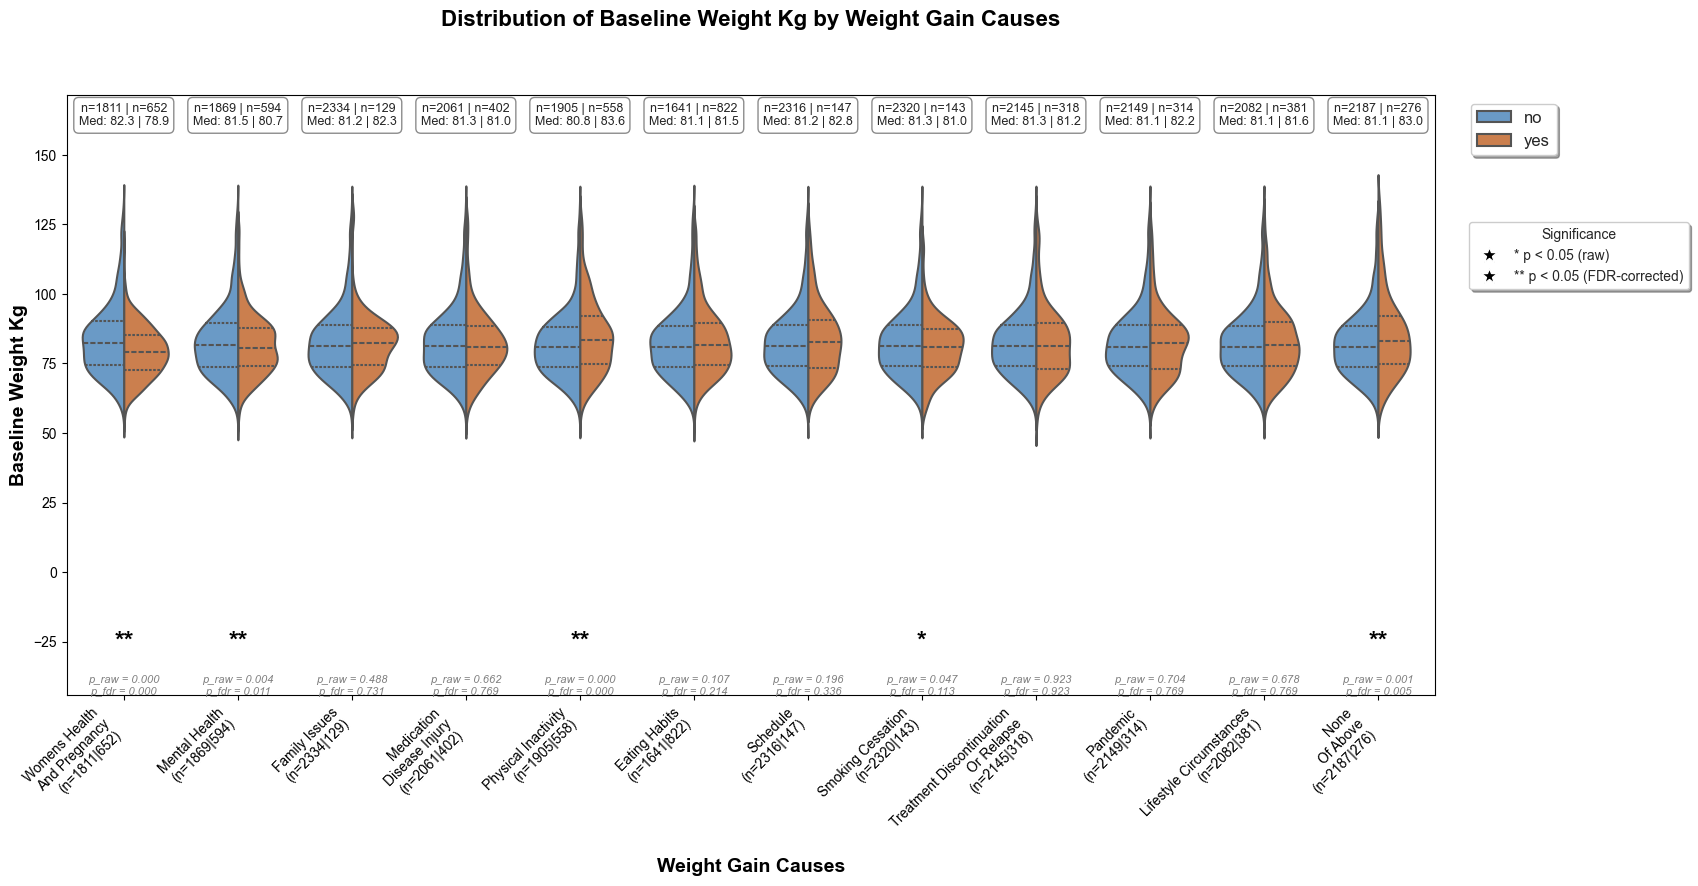

Investigating data for total_wl_%:
  Min value: -36.14595210946408
  Max value: 12.434554973821989
  Negative values count: 2266
Performing statistical tests for total_wl_%...
  womens_health_and_pregnancy: p-value = 0.6037
  mental_health: p-value = 0.7959
  family_issues: p-value = 0.5873
  medication_disease_injury: p-value = 0.2626
  physical_inactivity: p-value = 0.1120
  eating_habits: p-value = 0.4821
  schedule: p-value = 0.7070
  smoking_cessation: p-value = 0.4649
  treatment_discontinuation_or_relapse: p-value = 0.8347
  pandemic: p-value = 0.0366
  lifestyle_circumstances: p-value = 0.1780
  none_of_above: p-value = 0.6163
Applied FDR correction to 12 tests


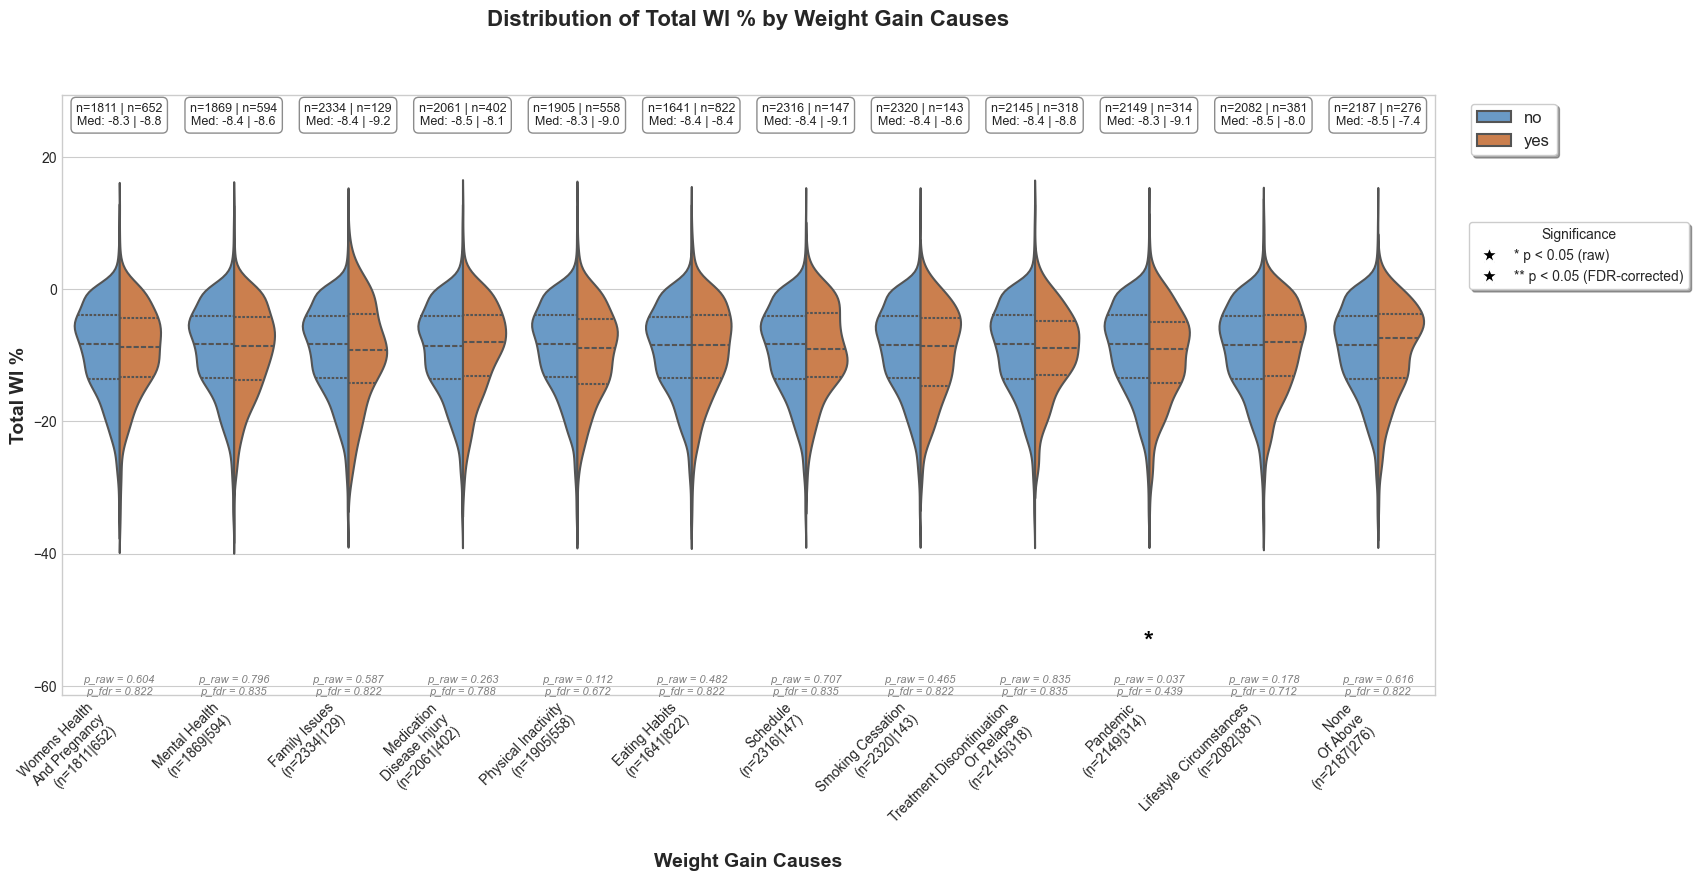

Investigating data for total_followup_days:
  Min value: 1
  Max value: 991
  Negative values count: 0
Performing statistical tests for total_followup_days...
  womens_health_and_pregnancy: p-value = 0.8939
  mental_health: p-value = 0.5066
  family_issues: p-value = 0.3465
  medication_disease_injury: p-value = 0.9325
  physical_inactivity: p-value = 0.0187
  eating_habits: p-value = 0.7600
  schedule: p-value = 0.2965
  smoking_cessation: p-value = 0.6901
  treatment_discontinuation_or_relapse: p-value = 0.0601
  pandemic: p-value = 0.0038
  lifestyle_circumstances: p-value = 0.7042
  none_of_above: p-value = 0.2630
Applied FDR correction to 12 tests


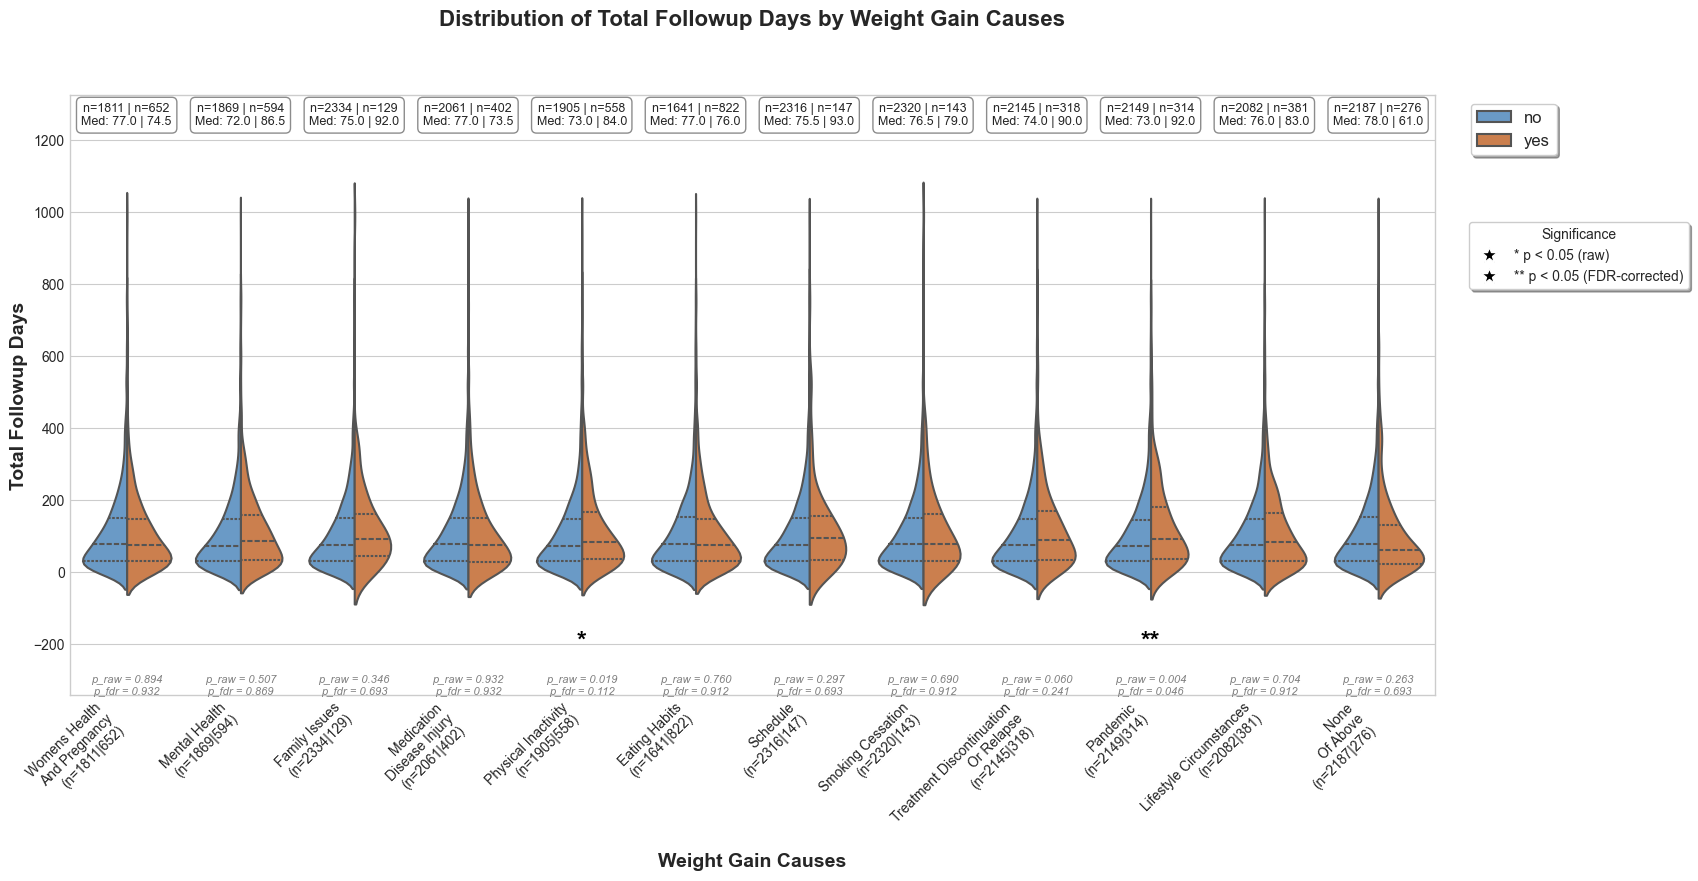

In [1]:
# Import and run enhanced violin plots with statistical testing
import sys
sys.path.append('scripts')
from wgc_violin_plots import ViolinPlotConfig, get_wgc_columns, create_enhanced_split_violin_plot
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

def plot_enhanced_violin_plots():
    db_path = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper2_dir\dbs\pnk_db2_p2_in.sqlite"
    with sqlite3.connect(db_path) as conn:
        df = pd.read_sql_query("SELECT * FROM timetoevent_wgc_compl", conn)
    
    wgc_cols = get_wgc_columns(df)
    config = ViolinPlotConfig()
    
    variables = ["baseline_weight_kg", "total_wl_%", "total_followup_days"]
    
    for var in variables:
        fig = create_enhanced_split_violin_plot(df, var, wgc_cols, config)
        plt.show()

# Usage: 
plot_enhanced_violin_plots()


### I/2. Influence of weight gain causes in weight loss-related predictions

#### I/2.3. Regression analyses

##### I/2.3. logistic - outcomes

In [ ]:
# IMPORTS 
import os
import pandas as pd
from regressions_inference import (
    load_data, 
    generate_logreg_scenarios,
    run_logreg_pipeline
)

# I/O databases
INPUT_DB = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper2_dir\pnk_db2_p2_in.sqlite"
OUTPUT_DB = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper2_dir\pnk_db2_p2_out.sqlite"

# Uncomment I/O tables to use

INPUT_TABLE = "timetoevent_wgc_compl"
OUTPUT_TABLE = "lg_outcms_wgc_cmpl"

# INPUT_TABLE = "timetoevent_wgc_gen_compl"
# OUTPUT_TABLE = "lg_outcms_wgc_gen_cmpl"

# Load once for scenario generation
df_all = load_data(INPUT_DB, INPUT_TABLE)

outcome_types = [
    'target_wl',
    'dropout'
]
time_windows = [
    40, 
    60, 
    80, 
    'total'  # Can also use total follow-up time
]
target_percentages = [
    5, 
    10, 
    15
]
main_predictors = [
        "womens_health_and_pregnancy",
        "mental_health",
        "family_issues",
        "medication_disease_injury",
        "physical_inactivity",
        "eating_habits",
        "schedule",
        "smoking_cessation",
        "treatment_discontinuation_or_relapse",
        "pandemic",
        "lifestyle_circumstances",
        "none_of_above"
]

adjustment_sets = [
    ([], "unadjusted"),
    (['age', 'sex_f', 'baseline_bmi'], "adjusted")
]

LOGREG_SCENARIOS = generate_logreg_scenarios(
    outcome_types, time_windows, target_percentages, main_predictors, adjustment_sets,
    input_table=INPUT_TABLE, df_all=df_all
)

run_logreg_pipeline(INPUT_DB, INPUT_TABLE, LOGREG_SCENARIOS, OUTPUT_TABLE, OUTPUT_DB)

##### I/2.3. linear - outcomes

In [ ]:
# IMPORTS 
import os
import pandas as pd
from regressions_inference import (
    load_data, 
    generate_linreg_scenarios,
    run_linreg_pipeline
)

# I/O databases
INPUT_DB = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper2_dir\pnk_db2_p2_in.sqlite"
OUTPUT_DB = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper2_dir\pnk_db2_p2_out.sqlite"

# Uncomment I/O tables to use

INPUT_TABLE = "timetoevent_wgc_compl"
OUTPUT_TABLE = "ln_outcms_wgc_compl"

# INPUT_TABLE = "timetoevent_wgc_gen_compl"
# OUTPUT_TABLE = "ln_outcms_wgc_gen_compl"

# Load once for scenario generation
df_all = load_data(INPUT_DB, INPUT_TABLE)

outcome_types = ['weight_change', 'fat_change', 'muscle_change']
time_windows = [40, 60, 80, 'total']
main_predictors = [
        "womens_health_and_pregnancy",
        "mental_health",
        "family_issues",
        "medication_disease_injury",
        "physical_inactivity",
        "eating_habits",
        "schedule",
        "smoking_cessation",
        "treatment_discontinuation_or_relapse",
        "pandemic",
        "lifestyle_circumstances",
        "none_of_above"
]
adjustment_sets = [
    ([], "unadjusted"),
    (['age', 'sex_f', 'baseline_bmi'], "adjusted")
]

LINREG_SCENARIOS = generate_linreg_scenarios(
    outcome_types, time_windows, main_predictors, adjustment_sets,
    input_table=INPUT_TABLE, df_all=df_all
)

run_linreg_pipeline(INPUT_DB, INPUT_TABLE, LINREG_SCENARIOS, OUTPUT_TABLE, OUTPUT_DB)

##### I/2.3. linear - adherence

In [ ]:
# IMPORTS
import os
import pandas as pd
from regressions_inference import (
    load_data, 
    generate_adherence_scenarios,
    run_adherence_linreg_pipeline
)

# I/O databases
INPUT_DB = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper2_dir\pnk_db2_p2_in.sqlite"
OUTPUT_DB = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\paper2_dir\pnk_db2_p2_out.sqlite"

# Uncomment I/O tables to use
INPUT_TABLE = "timetoevent_wgc_compl"
OUTPUT_TABLE = "ln_adher_wgc_compl"

# INPUT_TABLE = "timetoevent_wgc_gen_compl"
# OUTPUT_TABLE = "ln_adher_wgc_gen_compl"

# Load once for scenario generation
df_all = load_data(INPUT_DB, INPUT_TABLE)

adherence_outcomes = [
    'total_followup_days',
    'dietitian_visits',
    'nr_total_measurements',
    'avg_days_between_measurements'
    # days_to_X%_wl handled separately
]
target_percentages = [5, 10, 15]
main_predictors = [
        "womens_health_and_pregnancy",
        "mental_health",
        "family_issues",
        "medication_disease_injury",
        "physical_inactivity",
        "eating_habits",
        "schedule",
        "smoking_cessation",
        "treatment_discontinuation_or_relapse",
        "pandemic",
        "lifestyle_circumstances",
        "none_of_above"
]
adjustment_sets = [
    ([], "unadjusted"),
    (['age', 'sex_f', 'baseline_bmi'], "adjusted")
]

ADHERENCE_SCENARIOS = generate_adherence_scenarios(
    target_percentages,
    main_predictors,
    adjustment_sets,
    input_table=INPUT_TABLE,
    df_all=df_all,
    extra_outcomes=adherence_outcomes
)

run_adherence_linreg_pipeline(INPUT_DB, INPUT_TABLE, ADHERENCE_SCENARIOS, OUTPUT_TABLE, OUTPUT_DB)

# Misc

### SQL to Excel

list tables

In [8]:
import pandas as pd
import os
import sqlite3

db_directory = "C:\\Users\\Felhasználó\\Desktop\\Projects\\PNK_DB2\\DB2_standard"  # Paper 2-specific files and code
db_path = os.path.join(db_directory, "pnk_db2_filtered.sqlite")

with sqlite3.connect(db_path) as conn:
    tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)
    print('Tables in the database:')
    for name in tables['name']:
        print(f'"{name}",')

Tables in the database:
"measurements_filtered",
"medical_records_filtered",
"prescriptions_filtered",
"alleles_filtered",
"patients_filtered",


In [9]:
import sqlite3
import pandas as pd
import os

db_directory = "C:\\Users\\Felhasználó\\Desktop\\Projects\\PNK_DB2\\DB2_standard"  # Paper 2-specific files and code
output_directory = "C:\\Users\\Felhasználó\\Desktop\\Projects\\PNK_DB2\\DB2_standard"  # Paper 2-specific files and code

# Define the output Excel file path
DB_PATH = os.path.join(db_directory, "pnk_db2_filtered.sqlite")
output_excel_path = os.path.join(output_directory, 'alleles_filtered.xlsx')

# Define which tables to write to Excel (modify this list as needed)
tables_to_write = [
"alleles_filtered",
]

# Alternative: Set to None to export all tables (original behavior)
# tables_to_write = None

# Connect to the SQLite database
with sqlite3.connect(DB_PATH) as conn:
    # Get the list of all tables in the database
    query = "SELECT name FROM sqlite_master WHERE type='table';"
    all_tables = pd.read_sql_query(query, conn)['name'].tolist()
    
    # Determine which tables to export
    if tables_to_write is None:
        # Export all tables (original behavior)
        tables_to_export = all_tables
        print(f"Exporting all {len(tables_to_export)} tables to Excel...")
    else:
        # Export only specified tables
        tables_to_export = [table for table in tables_to_write if table in all_tables]
        missing_tables = [table for table in tables_to_write if table not in all_tables]
        
        if missing_tables:
            print(f"Warning: The following tables were not found in the database: {missing_tables}")
        
        print(f"Exporting {len(tables_to_export)} selected tables to Excel...")
        print(f"Tables to export: {tables_to_export}")
    
    # Create a Pandas Excel writer
    with pd.ExcelWriter(output_excel_path, engine='openpyxl') as writer:
        # Loop through each selected table and save it as a sheet in the Excel file
        for table in tables_to_export:
            try:
                df = pd.read_sql_query(f"SELECT * FROM {table}", conn)
                # Truncate sheet name if too long (Excel limit is 31 characters)
                sheet_name = table[:31] if len(table) > 31 else table
                df.to_excel(writer, sheet_name=sheet_name, index=False)
                print(f"  ✓ Exported table '{table}' ({len(df)} rows)")
            except Exception as e:
                print(f"  ✗ Error exporting table '{table}': {e}")

print(f"\nDatabase export completed. Excel file saved at: {output_excel_path}")


Exporting 1 selected tables to Excel...
Tables to export: ['alleles_filtered']
  ✓ Exported table 'alleles_filtered' (57859 rows)

Database export completed. Excel file saved at: C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\DB2_standard\alleles_filtered.xlsx


### SQL table listing and deletion

list tables

In [40]:
import pandas as pd
import os
import sqlite3

db_path = os.path.join(paper2_directory, "pnk_db2_p2_out.sqlite")

with sqlite3.connect(db_path) as conn:
    tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)
    print('Tables in the database:')
    for name in tables['name']:
        print(f'"{name}",')

Tables in the database:
"wgc_cmpl_dmgrph_strt",
"wgc_cmpl_wgc_strt",
"wgc_gen_cmpl_dmgrph_strt",
"wgc_gen_cmpl_wgc_strt",
"lg_outcms_wgc_cmpl",
"ln_outcms_wgc_compl",
"ln_adher_wgc_compl",
"bl_nobc_bw_hclust_ward_k3",
"bl_nobc_bw_hclust_ward_k8",
"bl_nobc_vw_hclust_ward_k6",
"bl_nobc_vw_hclust_ward_k7",
"bl_nobc_vw_hclust_ward_k8",
"bl_nobc_vw_pam_goldstd_k6",
"bl_nobc_vw_pam_goldstd_k7",
"bl_nobc_bw_pam_goldstd_k7",
"bl_nobc_bw_pam_goldstd_k6",
"bl_nobc_bw_pam_default_k7",
"bl_nobc_bw_pam_default_k6",
"jaccard_wgc_pam_goldstd_k6",
"jaccard_wgc_pam_goldstd_k7",


del tables

In [29]:
import sqlite3
import os

paper2_directory = "C:\\Users\\Felhasználó\\Desktop\\Projects\\PNK_DB2\\paper2_dir"  # Paper 2-specific files and code
db_path = os.path.join(paper2_directory, "pnk_db2_p2_out.sqlite")

# List of tables to delete
tables_to_delete = [
"jaccard_wgc_pam_goldstd_k7",
"jaccard_wgc_pam_goldstd_k6",
"bl_nobc_bw_pam_goldstd_k7",
"bl_nobc_vw_pam_goldstd_k7",
"bl_nobc_vw_pam_goldstd_k6",
]

with sqlite3.connect(db_path) as conn:
    cursor = conn.cursor()
    for table in tables_to_delete:
        cursor.execute(f"DROP TABLE IF EXISTS {table}")
    conn.commit()
print("Selected tables deleted from the defined database.")

Selected tables deleted from the defined database.


### SQL table column deletion

In [ ]:
import sqlite3

paper2_directory = "C:\\Users\\Felhasználó\\Desktop\\Projects\\PNK_DB2\\paper2_dir"  # Paper 2-specific files and code
db_path = os.path.join(paper2_directory, "pnk_db2_p2_in.sqlite")

# Get the table name
with sqlite3.connect(db_path) as conn:
    table_name = conn.execute("SELECT name FROM sqlite_master WHERE type='table';").fetchone()[0]
    # Get all columns
    columns = [row[1] for row in conn.execute(f"PRAGMA table_info([{table_name}]);")]
    # Find index of 'weight_gain_cause_en'
    idx = columns.index('weight_gain_cause_en')
    # Columns to keep (up to and including 'weight_gain_cause_en')
    keep_cols = columns[:idx+1]
    # Columns to drop (after 'weight_gain_cause_en')
    drop_cols = columns[idx+1:]

    if drop_cols:
        # Build new table schema
        col_defs = ", ".join([
            f"{row[1]} {row[2]}"
            for row in conn.execute(f"PRAGMA table_info([{table_name}]);")
            if row[1] in keep_cols
        ])
        new_table = f"{table_name}_tmp"

        # Create new table
        conn.execute(f"CREATE TABLE [{new_table}] ({col_defs});")
        # Copy data
        conn.execute(f"INSERT INTO [{new_table}] SELECT {', '.join(keep_cols)} FROM [{table_name}];")
        # Drop old table
        conn.execute(f"DROP TABLE [{table_name}];")
        # Rename new table
        conn.execute(f"ALTER TABLE [{new_table}] RENAME TO [{table_name}];")
        conn.commit()
        print(f"Columns after '{keep_cols[-1]}' have been deleted from '{table_name}'.")
    else:
        print("No columns to delete after 'weight_gain_cause_en'.")

In [ ]:
import sqlite3
import os

db_path = os.path.join(paper1_directory, "pnk_db2_p1.sqlite")
table_name = "timetoevent_all"
col_to_delete = "genomics_sample_id"

with sqlite3.connect(db_path) as conn:
    # Get all columns
    columns = [row[1] for row in conn.execute(f"PRAGMA table_info([{table_name}]);")]
    if col_to_delete not in columns:
        print(f"Column '{col_to_delete}' not found in '{table_name}'. No action taken.")
    else:
        keep_cols = [col for col in columns if col != col_to_delete]
        col_defs = ", ".join([
            f"{row[1]} {row[2]}"
            for row in conn.execute(f"PRAGMA table_info([{table_name}]);")
            if row[1] in keep_cols
        ])
        tmp_table = f"{table_name}_tmp"
        # Create new table without the column
        conn.execute(f"CREATE TABLE [{tmp_table}] ({col_defs});")
        # Copy data
        conn.execute(f"INSERT INTO [{tmp_table}] SELECT {', '.join(keep_cols)} FROM [{table_name}];")
        # Drop old table and rename new
        conn.execute(f"DROP TABLE [{table_name}];")
        conn.execute(f"ALTER TABLE [{tmp_table}] RENAME TO [{table_name}];")
        conn.commit()
        print(f"Column '{col_to_delete}' deleted from '{table_name}'.")

### DW/SQL queries

In [1]:
import sqlite3
import pandas as pd

db_path = r"C:\Users\Felhasználó\Desktop\Projects\PNK_DB2\genomics_dir\dbs\pnk_db2_filtered.sqlite"
table_name = "alleles_filtered"

with sqlite3.connect(db_path) as conn:
    df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)

unique_patient_ids = df['patient_id'].nunique()
print(f"Number of unique values in 'patient_id': {unique_patient_ids}")

Number of unique values in 'patient_id': 2396


In [ ]:
df